In [1]:
from pathlib import Path

import os

mplconfig_dir = Path(r"results/lse_variance/.mplconfig_visualize2")
mplconfig_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mplconfig_dir.resolve()))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.lines import Line2D

npz_path = Path(r"results/lse_variance/lse_variance_metrics.npz")
output_dir = npz_path.parent
output_dir.mkdir(parents=True, exist_ok=True)


In [2]:
metric_groups = {
    "V_1st": ("V_1st", "V_1st_std"),
    "V_full": ("V_full", "V_full_std"),
    "abs_gap": ("abs_gap", "abs_gap_std"),
    "rel_gap": ("rel_gap", "rel_gap_std"),
}


def tau_to_float(tag: str) -> float:
    return float(tag.replace("p", "."))


def tau_to_label(tag: str) -> str:
    return rf"$\tau={tau_to_float(tag):g}$"


with np.load(npz_path) as payload:
    checkpoints = payload["checkpoints"]
    tau_tags = sorted(
        {key[4:].split("_", 1)[0] for key in payload.files if key.startswith("tau_")},
        key=tau_to_float,
    )

    records = []
    for tag in tau_tags:
        tau_value = tau_to_float(tag)
        tau_label = tau_to_label(tag)
        for metric_name, (mean_suffix, std_suffix) in metric_groups.items():
            mean_key = f"tau_{tag}_{mean_suffix}"
            std_key = f"tau_{tag}_{std_suffix}"
            values = payload[mean_key]
            stds = payload[std_key]
            for step, value, std in zip(checkpoints, values, stds):
                records.append(
                    {
                        "tau": tau_value,
                        "tau_label": tau_label,
                        "step": int(step),
                        "metric": metric_name,
                        "value": float(value),
                        "std": float(std),
                    }
                )

df = pd.DataFrame.from_records(records)


## LSE Variance Experiment

`lse_variance.py` quantifies the higher-order error in the log-sum-exp (LSE) decision-variance surrogate used by `VarDE_lse`.

For each temperature `tau`, the script runs `VarDE_lse` on the default 10-arm Gaussian instance, records the empirical mean / variance / pull-count history, and compares two quantities at each decision step:

- `V_1st = \sum_i w_i(\hat{\mu}_t)^2 \, \hat{\sigma}_i^2 / N_i`, the first-order delta-method approximation.
- `V_full = \mathrm{Var}[f_\tau(\tilde{\mu}_t)]`, where `f_\tau` is the LSE objective and `\tilde{\mu}_{t,i} \sim \mathcal{N}(\hat{\mu}_{t,i}, \hat{\sigma}_i^2 / N_i)` independently across arms.

The full variance is estimated by Monte Carlo under that empirical Gaussian sampling law. The notebook below loads the stored archive `results/lse_variance/lse_variance_metrics.npz` and summarizes the small-temperature regime that is most relevant to the reviewer concern.


In [3]:
selected_steps = [20, 100, 200, 400, 600, 800, int(checkpoints.max())]


def make_tau_table(tau: float):
    tau_frame = df[
        (df["tau"] == tau)
        & (df["metric"].isin(["V_full", "V_1st", "abs_gap", "rel_gap"]))
        & (df["step"].isin(selected_steps))
    ]
    table = (
        tau_frame.pivot(index="step", columns="metric", values="value")
        .reindex(selected_steps)
        [["V_full", "V_1st", "abs_gap", "rel_gap"]]
        .rename_axis(index="decision_step", columns=None)
    )
    return table.style.format(
        {
            "V_full": "{:.3e}",
            "V_1st": "{:.3e}",
            "abs_gap": "{:.3e}",
            "rel_gap": "{:.1%}",
        }
    ).set_caption(
        f"Table: LSE decision-variance gap for tau={tau:g}"
    )


In [4]:
display(Markdown("### Table 1: $\\tau = 0.05$"))
display(make_tau_table(0.05))


### Table 1: $\tau = 0.05$

,V_full,V_1st,abs_gap,rel_gap
decision_step,,,,
20,1.227e-02,3.838e-03,8.510e-03,66.4%
100,7.467e-03,9.626e-04,6.507e-03,84.4%
200,5.409e-03,5.022e-04,4.908e-03,87.7%
400,3.659e-03,2.530e-04,3.406e-03,88.7%
600,2.790e-03,1.687e-04,2.622e-03,88.0%
800,2.243e-03,1.268e-04,2.116e-03,86.5%
979,1.916e-03,1.027e-04,1.813e-03,84.9%


In [5]:
display(Markdown("### Table 2: $\\tau = 0.10$"))
display(make_tau_table(0.10))


### Table 2: $\tau = 0.10$

,V_full,V_1st,abs_gap,rel_gap
decision_step,,,,
20,7.112e-03,2.911e-03,4.201e-03,56.1%
100,1.998e-03,8.603e-04,1.137e-03,50.2%
200,8.728e-04,4.618e-04,4.111e-04,37.1%
400,3.609e-04,2.398e-04,1.211e-04,21.6%
600,2.157e-04,1.621e-04,5.369e-05,14.4%
800,1.529e-04,1.224e-04,3.065e-05,10.6%
979,1.198e-04,1.003e-04,1.963e-05,8.4%


In [6]:
display(Markdown("### Table 3: $\\tau = 0.15$"))
display(make_tau_table(0.15))


### Table 3: $\tau = 0.15$

,V_full,V_1st,abs_gap,rel_gap
decision_step,,,,
20,4.644e-03,2.712e-03,1.933e-03,39.5%
100,1.102e-03,8.461e-04,2.562e-04,20.4%
200,5.197e-04,4.580e-04,6.169e-05,10.7%
400,2.540e-04,2.390e-04,1.534e-05,5.3%
600,1.682e-04,1.617e-04,7.276e-06,3.8%
800,1.258e-04,1.222e-04,4.626e-06,3.2%
979,1.026e-04,1.003e-04,3.339e-06,3.0%


In [7]:
skip_step = 0  # increase this if you want to hide the earliest transient regime

df = df[df["step"] >= skip_step].copy()
tau_order = [tau_to_label(tag) for tag in tau_tags]

df_variance = df[df["metric"].isin(["V_1st", "V_full"])].copy()
df_variance["approximation"] = pd.Categorical(
    df_variance["metric"],
    categories=["V_full", "V_1st"],
    ordered=True,
)

df_gap = df[df["metric"].isin(["abs_gap", "rel_gap"])].copy()

summary_rows = []
for tag in tau_tags:
    tau_value = tau_to_float(tag)
    tau_frame = df[df["tau"] == tau_value]
    final_frame = tau_frame[tau_frame["step"] == tau_frame["step"].max()].set_index("metric")
    abs_gap_frame = tau_frame[tau_frame["metric"] == "abs_gap"]
    rel_gap_frame = tau_frame[tau_frame["metric"] == "rel_gap"]
    max_abs = abs_gap_frame.loc[abs_gap_frame["value"].idxmax()]
    max_rel = rel_gap_frame.loc[rel_gap_frame["value"].idxmax()]
    summary_rows.append(
        {
            "tau": tau_value,
            "final_step": int(final_frame["step"].iloc[0]),
            "final_V_1st": float(final_frame.loc["V_1st", "value"]),
            "final_V_full": float(final_frame.loc["V_full", "value"]),
            "final_abs_gap": float(final_frame.loc["abs_gap", "value"]),
            "final_rel_gap": float(final_frame.loc["rel_gap", "value"]),
            "max_abs_gap": float(max_abs["value"]),
            "max_abs_step": int(max_abs["step"]),
            "max_rel_gap": float(max_rel["value"]),
            "max_rel_step": int(max_rel["step"]),
        }
    )

df_summary = pd.DataFrame.from_records(summary_rows).sort_values("tau").reset_index(drop=True)


In [8]:
summary_by_tau = df_summary.set_index("tau")
small_taus = [0.05, 0.10, 0.15]
lines = ["## Remarks on the Results", ""]
for tau in small_taus:
    row = summary_by_tau.loc[tau]
    step20 = df[(df["tau"] == tau) & (df["step"] == 20)].set_index("metric")
    lines.append(
        (
            f"- At $\\tau={tau:g}$, the relative gap moves from {step20.loc['rel_gap', 'value']:.1%} at step 20 "
            f"to {row['final_rel_gap']:.1%} at the final step {int(row['final_step'])}; the final absolute gap is "
            f"{row['final_abs_gap']:.3e}."
        )
    )
lines.append(
    (
        f"- In the stored sweep, the largest absolute gap occurs at the earliest checkpoint for every tested tau; "
        f"for the larger temperatures, the final relative gap is {summary_by_tau.loc[0.2, 'final_rel_gap']:.1%} at $\\tau=0.2$ "
        f"and {summary_by_tau.loc[0.5, 'final_rel_gap']:.1%} at $\\tau=0.5$."
    )
)
lines.append(
    "- The evidence supports the reviewer concern in the very small-temperature regime: omitting higher-order terms is unsafe at $\\tau=0.05$, while the approximation becomes much tighter by $\\tau=0.1$--$0.15$ once the run leaves the earliest transient."
)
display(Markdown("\n".join(lines)))


## Remarks on the Results

- At $\tau=0.05$, the relative gap moves from 66.4% at step 20 to 84.9% at the final step 979; the final absolute gap is 1.813e-03.
- At $\tau=0.1$, the relative gap moves from 56.1% at step 20 to 8.4% at the final step 979; the final absolute gap is 1.963e-05.
- At $\tau=0.15$, the relative gap moves from 39.5% at step 20 to 3.0% at the final step 979; the final absolute gap is 3.339e-06.
- In the stored sweep, the largest absolute gap occurs at the earliest checkpoint for every tested tau; for the larger temperatures, the final relative gap is 2.6% at $\tau=0.2$ and 2.5% at $\tau=0.5$.
- The evidence supports the reviewer concern in the very small-temperature regime: omitting higher-order terms is unsafe at $\tau=0.05$, while the approximation becomes much tighter by $\tau=0.1$--$0.15$ once the run leaves the earliest transient.

In [9]:
base_rcparams = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
}


def apply_plot_style(prefer_tex: bool = True) -> bool:
    mpl.rcParams.update(base_rcparams)
    sns.set_theme(style="whitegrid")
    if not prefer_tex:
        mpl.rcParams["text.usetex"] = False
        return False

    tex_rcparams = dict(base_rcparams)
    tex_rcparams.update({
        "text.usetex": True,
        "text.latex.preamble": r"""
            \usepackage{newtxtext}
            \usepackage{newtxmath}
        """,
    })
    try:
        mpl.rcParams.update(tex_rcparams)
        probe = plt.figure(figsize=(0.5, 0.5))
        probe.text(0.5, 0.5, r"$\tau$", ha="center", va="center")
        probe.canvas.draw()
        plt.close(probe)
        return True
    except Exception:
        plt.close("all")
        mpl.rcParams.update(base_rcparams)
        mpl.rcParams["text.usetex"] = False
        return False


use_tex = apply_plot_style(prefer_tex=True)
palette = ["#1F77B4", "#2CA02C", "#6A3D9A", "#D62728", "#FF8C00"]
tau_palette = dict(zip(tau_order, sns.color_palette(palette, n_colors=len(tau_order))))


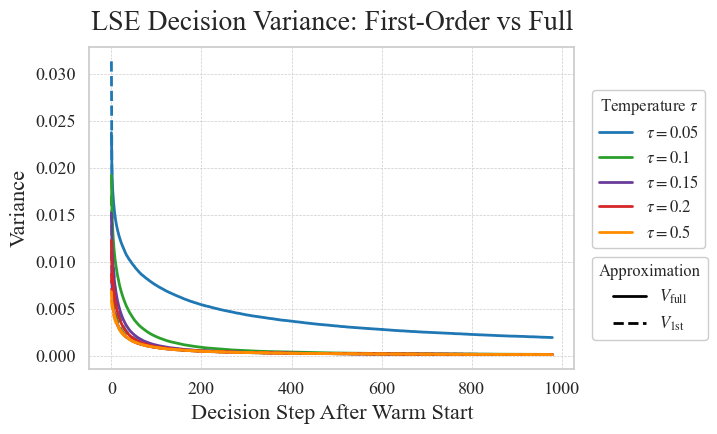

In [10]:
title = "LSE Decision Variance: First-Order vs Full"
out_path = output_dir / "lse_variance_variance_comparison.pdf"

plt.figure(figsize=(9, 4.5))
ax = plt.gca()

for tau_label in tau_order:
    color = tau_palette[tau_label]
    for approximation, linestyle in [("V_full", "-"), ("V_1st", "--")]:
        subset = df_variance[
            (df_variance["tau_label"] == tau_label)
            & (df_variance["approximation"] == approximation)
        ].sort_values("step")
        ax.plot(
            subset["step"],
            subset["value"],
            color=color,
            linestyle=linestyle,
            linewidth=2.0,
            alpha=1.0,
        )

tau_handles = [
    Line2D([0], [0], color=tau_palette[tau_label], lw=2.0, label=tau_label)
    for tau_label in tau_order
]
approx_handles = [
    Line2D([0], [0], color="black", lw=2.0, linestyle="-", label=r"$V_{\mathrm{full}}$"),
    Line2D([0], [0], color="black", lw=2.0, linestyle="--", label=r"$V_{\mathrm{1st}}$"),
]

legend_tau = ax.legend(
    handles=tau_handles,
    title=r"Temperature $\tau$",
    loc="center left",
    bbox_to_anchor=(1.02, 0.62),
    framealpha=1.0,
)
ax.add_artist(legend_tau)
ax.legend(
    handles=approx_handles,
    title="Approximation",
    loc="center left",
    bbox_to_anchor=(1.02, 0.22),
    framealpha=1.0,
)

ax.set_title(title, pad=12)
ax.set_xlabel("Decision Step After Warm Start")
ax.set_ylabel("Variance")
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=1.0)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig(out_path, bbox_inches="tight")


In [11]:
plot_specs = [
    ("abs_gap", "Higher-Order Contribution", "Absolute Gap", output_dir / "lse_variance_abs_gap.pdf"),
    ("rel_gap", "Relative Higher-Order Contribution", "Relative Gap", output_dir / "lse_variance_rel_gap.pdf"),
]

saved_paths = []
for metric_name, title, ylabel, out_path in plot_specs:
    plt.figure(figsize=(9, 4))
    ax = plt.gca()

    for tau_label in tau_order:
        color = tau_palette[tau_label]
        subset = df_gap[
            (df_gap["metric"] == metric_name)
            & (df_gap["tau_label"] == tau_label)
        ].sort_values("step")
        x = subset["step"].to_numpy()
        y = subset["value"].to_numpy()
        std = subset["std"].to_numpy()
        lower = np.clip(y - std, a_min=0.0, a_max=None)
        upper = y + std

        ax.plot(x, y, color=color, linewidth=2.0, alpha=1.0, label=tau_label)
        ax.fill_between(x, lower, upper, color=color, alpha=0.12, linewidth=0.0)

    ax.set_title(title, pad=12)
    ax.set_xlabel("Decision Step After Warm Start")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=1.0)
    ax.legend(
        title=r"Temperature $\tau$",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        framealpha=1.0,
    )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()
    saved_paths.append(out_path)

saved_paths


[WindowsPath('results/lse_variance/lse_variance_abs_gap.pdf'),
 WindowsPath('results/lse_variance/lse_variance_rel_gap.pdf')]